# Computer Exercise 15.33 — Problem 1
## 판정 규칙의 교정 — 그리고 **귀무가설 자체의 교정**

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 §15.33
> **단원**: Ch 15 Sequential Decision Making — §15.33 Calibrated Protocol (v2)
> **풀이 일자**: 2026-08-18 (Day 100)
> **언어**: Python 3.10 · NumPy / pandas / SciPy / Matplotlib
>
> Day 99 P3 은 지난 30 일이 써 온 1 차 판정 규칙 — 백분위 bootstrap 신뢰구간이 0 을 배제하면
> 유의 — 이 A/A 조건에서 1 종 오류를 $0.094$ (비짝지음 귀무) / $0.064$ (배포 전용 귀무) 로
> 낸다고 실측했다. 목표는 $0.05$ 다.
>
> Day 100 은 자를 고치려 했고, 고치는 과정에서 **자를 재던 저울이 먼저 흔들린다**는 것을
> 발견했다. Day 99 의 "배포 전용 귀무" 는 **고정된 한 쌍의 배포 스트림**으로 구성되어 있고,
> 그 구성은 측정되지 않은 성가신 모수 — 그 한 쌍이 우연히 갖게 된 풀 평균의 치우침 —
> 에 결과가 좌우된다. 아래 [4] 셀은 가능한 $\binom{8}{2}=28$ 쌍 **전부**에 대해 1 종 오류를
> 재어, 같은 규칙·같은 자료·같은 $n$ 인데 기각률이 한 자릿수 배로 흔들린다는 것을 보인다.
> **한 번 뽑은 값으로는 교정할 수 없다.** 원인을 지목하고, 재무작위화된 귀무를 구성하고,
> 그 위에서 다시 교정한다.

## 1. 문제 (원문)

> **Computer Exercise 15.33.1.** The decision rule used throughout Exercises 15.23–15.32 was
> "reject when the percentile bootstrap $95\%$ interval of the paired difference excludes zero."
> Exercise 15.32 measured its A/A type-I error against two constructed nulls. **Calibrate a
> replacement — and validate the calibration apparatus itself.**
> Generate an independent pool of $N = 80$ training seeds for the baseline learner and for the
> frozen-$\sigma$ control at the fixed budget $T = 10^4$, and deploy every learner under $K = 8$
> independent deployment streams. Estimate by Monte Carlo ($M = 1000$) the A/A type-I error of four
> candidate rules — percentile bootstrap interval, $\mathrm{BC}_a$ interval, sign-flip permutation
> test, paired $t$ — at $n \in \{10,20,30,40\}$. **Verify that each constructed null is in fact a
> null** by checking that the rejection rate does not increase with $n$; diagnose and repair any
> null that fails this check. Then estimate the family-wise error rate of $m = 3$ comparisons
> sharing a common reference arm, with and without Holm. Finally report the power of the calibrated
> rule for the observed `fix_big` $-$ `base` difference and the resulting $n^\dagger$.

### 한국어 풀이용 정리

Day 100 P1 은 실험이 아니라 **계측기 교정(calibration)** 이고, 교정에는 반드시
**교정 기준의 검증**이 따라야 한다. 세 층으로 잰다.

| 층 | 잴 것 | 합격 조건 |
|---|---|---|
| **0** | 구성한 귀무가 정말 귀무인가 | 기각률이 $n$ 에 대해 증가하지 않고, **구성의 임의 선택에 좌우되지 않을 것** |
| **1** | 네 규칙의 1 종 오류 | 모든 $n$, 모든 (검증 통과) 귀무에서 $\le 0.05 + \text{MC}$ |
| **2** | FWER, 검정력, $n^\dagger$ | FWER $\le 0.05$ (Holm), power $\ge 0.80$ |

**층 0 이 이 노트북의 핵심**이다. Day 99 는 층 1 만 재고 층 0 을 건너뛰었다.

세 개의 귀무를 쓴다.

- **N1 (비짝지음)** — 같은 arm 의 **서로 다른 시드** 두 묶음을 짝지어 차를 만든다.
  매 반복마다 분할을 새로 뽑으므로 재무작위화가 있다. 초기화 분산이 상쇄되지 않아 **분산 과대**.
- **N2 (배포 전용, Day 99 방식)** — 같은 학습기를 **고정된** 두 배포 스트림으로 배포한 차.
- **N2′ (배포 전용, 재무작위화)** — 같은 학습기를 $K=8$ 개 스트림 중 **매 반복 새로 뽑은**
  두 개로 배포한 차. 학습 분산이 상쇄되어 **분산 과소**.

N2 와 N2′ 의 유일한 차이는 재무작위화의 유무다. 결과는 그 차이가 결정적임을 보여 준다.

## 2. 수학적 배경

### 2.1 귀무의 검증 — 단조성 진단

효과가 정확히 0 인 자료에 수준 $\alpha$ 규칙을 적용하면, 규칙이 타당하든 아니든
기각률은 $n$ 이 커질수록 **명목 $\alpha$ 로 수렴하거나 그 아래로 내려간다**. 점근 규칙의
과다 기각은 작은 $n$ 에서 나타나고 $n$ 이 커지면 사라진다. 따라서

$$\boxed{\;\frac{\partial}{\partial n}\,\widehat{\alpha}_{\text{real}}(n) > 0 \ \text{가 지속되거나,}\ 
\widehat{\alpha}_{\text{real}} \ \text{가 } H_0 \text{ 구성의 임의 선택에 좌우되면, 문제는 규칙이 아니라 } H_0 \text{ 다.}\;}$$

**왜 그런가.** 크기 $N$ 의 고정된 벡터 $d^{\text{pool}} \in \mathbb R^N$ 에서 크기 $n$ 부분표본을
재추출해 검정하면, 검정이 실제로 다루는 귀무는

$$H_0^{\text{pool}} : \ \bar d^{\text{pool}} = \frac1N\sum_{i=1}^N d_i^{\text{pool}} = 0$$

이다. 모집단 평균이 0 이더라도 $\bar d^{\text{pool}}$ 은 $O(N^{-1/2})$ 크기의 난수이며
**표본을 바꿔도 사라지지 않는다.** $n \to N$ 이면 검정은 이 고정된 $\bar d^{\text{pool}}$ 을
점점 정확히 탐지하므로 기각률은 $n$ 과 함께 **증가**한다. 즉 부분표본 재추출은
$\bar d^{\text{pool}} \ne 0$ 인 순간 **A/A 가 아니라 A/B** 가 된다.

$\bar d^{\text{pool}}$ 은 **관측 불가능한 성가신 모수**다. 그 실현값이 우연히 0 에 가까우면
검정은 보수적으로 보이고 (기각률이 $n$ 과 함께 *감소*), 크면 반보수적으로 보인다 (증가).
어느 쪽이든 **측정된 것은 규칙의 성질이 아니라 그 한 번의 뽑기**다. 따라서 층 0 진단은
단조성 하나로 부족하며, **구성 가능한 모든 $H_0$ 에 대해 결과가 안정한지**를 함께 봐야 한다.

**처방은 재무작위화다.** 매 반복마다 $d_i$ 를 *새로* 생성하면 (N1 의 무작위 분할,
N2′ 의 스트림 재추출) $\bar d^{\text{pool}}$ 의 우연한 치우침이 반복 간에 평균되어 사라지고,
1 종 오류가 구성의 임의 선택에 의존하지 않게 된다.

### 2.2 네 규칙

$\bar d$ 를 표본평균, $\bar d^{*(b)}$ 를 $b$ 번째 bootstrap 재표본 평균이라 하자.

**(R1) 백분위 bootstrap CI.** $\big[\bar d^{*}_{(\alpha/2)},\ \bar d^{*}_{(1-\alpha/2)}\big]$ 가
0 을 배제하면 기각. 편의·왜도 보정이 없다.

**(R2) $\mathrm{BC}_a$.** $\hat z_0 = \Phi^{-1}\!\big(\#\{\bar d^{*(b)} < \bar d\}/B\big)$,
$\hat a = \sum_i u_i^3 \big/ 6\big(\sum_i u_i^2\big)^{3/2}$ ($u_i = \bar d_{(\cdot)} - \bar d_{(i)}$, jackknife) 로

$$\alpha_{\bullet} = \Phi\!\left(\hat z_0 + \frac{\hat z_0 + z_{\bullet}}{1 - \hat a(\hat z_0 + z_{\bullet})}\right),
\qquad \bullet \in \{\alpha/2,\ 1-\alpha/2\}.$$

**(R3) 부호뒤집기 순열검정.** $s_i^{(b)} \sim \text{Unif}\{-1,+1\}$,
$p = \big(1 + \#\{b: |\overline{s^{(b)}d}| \ge |\bar d|\}\big)/(B+1)$.
귀무분포가 **0 대칭**이라는 가정 하나만 쓰며, 그 가정 아래
$\Pr[p \le \alpha] \le \alpha$ 가 **$n$ 과 무관하게 유한표본에서** 성립한다.

**(R4) 짝지은 $t$.** $t = \bar d/(\hat{\mathrm{sd}}/\sqrt n) \sim t_{n-1}$, 정규성 가정.

R3 만이 유한표본 보장을 갖는다. 단, **그 보장은 대칭인 귀무에 대한 것**이므로
$\bar d^{\text{pool}} \ne 0$ 인 상황에서는 R3 도 무력하다 — 2.1 이 말하는 바가 정확히 이것이다.

### 2.3 배포 반복 평균과 분산 분해

시드 $i$, 배포 스트림 $k$ 의 return 을 $R_{ik}$ 라 하면

$$\mathrm{Var}(R_{ik}) = \underbrace{\sigma^2_{\text{train}}}_{\text{시드 간}}
+ \underbrace{\sigma^2_{\text{dep}}}_{\text{배포 난수}},
\qquad
\mathrm{Var}\Big(\tfrac1K\textstyle\sum_k R_{ik}\Big)
= \sigma^2_{\text{train}} + \frac{\sigma^2_{\text{dep}}}{K}.$$

$K$ 를 키우면 **배포 성분만** 줄어든다. 두 성분의 비를 실측하면, 시드를 늘려야 하는지
배포를 늘려야 하는지가 정해진다 — 시드 한 개는 학습 $T=10^4$ 을 요구하고 배포 한 번은
$800$ 스텝이므로 **비용 차이가 $25$ 배**다.

### 2.4 FWER, $n^\star$, $n^\dagger$

$m$ 독립 귀무에서 무보정 $\mathrm{FWER} = 1-(1-\alpha)^m = 0.1426$ ($m{=}3$).
Holm 은 임의의 종속에서 $\mathrm{FWER} \le \alpha$ 를 보장한다 (Holm 1979).

$$n^\star = \left\lceil \big(2.8\,\hat{\mathrm{sd}}/|\bar d|\big)^2 \right\rceil \ (\text{Cohen 근사}),
\qquad n^\dagger = \min\{n : \widehat{\text{power}}(n) \ge 0.80\}$$

$n^\dagger$ 은 관측된 차 벡터의 부분표본 재추출로 잰다 — 2.1 의 논리에 의해 이것은
**정당하다**: 검정력 계산에서는 $\bar d^{\text{pool}} \ne 0$ 이 결함이 아니라 **대상**이다.

## 3. 풀이 흐름

1. **독립 풀 생성** — 시드 $\{100001,\dots,100080\}$ (Day 99 의 99101–99460 과 비중첩) 에서
   `base` 와 `fix_big` ($\sigma \equiv 0.55$ 동결) 을 $T=10^4$ 로 학습하고, 각 학습기를
   $K=8$ 개 독립 배포 스트림으로 배포. 배포 난수는 (시드 인덱스, 스트림) 에만 의존 → **공통난수**.
2. **분산 분해** — $\sigma^2_{\text{train}}$ 대 $\sigma^2_{\text{dep}}$ 를 분리하고 $K$ 평균의 효과를 확인.
3. **층 0 진단** — 세 귀무 N1 · N2 · N2′ 에서 네 규칙의 기각률을 $n \in \{10,20,30,40\}$ 로 재고,
   나아가 N2 를 구성할 수 있는 $\binom{8}{2} = 28$ 개 스트림 쌍 **전부**에 대해 1 종 오류를 재어
   **구성 의존성**을 정량화. 안정하지 않은 귀무는 교정에서 배제.
4. **층 1 교정** — 검증을 통과한 귀무들에서만 네 규칙을 비교해 1 차 규칙을 고른다.
5. **FWER** — 80 시드를 크기 20 짜리 네 묶음으로 무작위 분할, 첫 묶음을 공통 기준으로 $m=3$ 비교.
6. **검정력** — 관측된 `fix_big`$-$`base` 차에서 부분표본 재추출($M=500$)로 $n^\dagger$ 산출.
   $K=1$ 과 $K=8$ 두 추정량을 나란히 비교.
7. **그림** — (Fig 1) 세 귀무 × 네 규칙의 1 종 오류 대 $n$. (Fig 2) FWER 막대 + 검정력 곡선.
8. **프로토콜 v2 확정** — 실측만으로 상수를 정하고 JSON 덤프. Problem 2·3 이 이를 쓴다.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t as tdist

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 정의 (Day 90–99 과 동일 계열의 5-상태 chain MDP 재구성) ──────
NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL, SIGMA0 = 0.95, 0.05, 16, 0.25, 0.5
SIG_INIT = SIGMA0 / np.sqrt(H)          # 0.125 — Noisy 헤드 sigma 의 초기값
SIG_BIG  = 0.55                          # Day 99 P2 의 fix_big (학습 종점에 맞춘 값)

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a                      # slip
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    r = 1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0)
    return s2, r

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

ARM_SPEC = {           # explore_noise, learn_sigma, inject_noise
    "base":  (False, False, False),
    "cnrt":  (True,  True,  True),
    "fixed": (True,  False, True),
    "inert": (False, False, False),
}

class Learner:
    """Trunk MLP (tanh, H=16) + linear head. Noisy 헤드는 (mu, sigma) 로 분해."""
    def __init__(self, rng, arm="base", sigma_decay=0.0, anneal=False, h=H,
                 sigma_init=None, sigma_pattern=None, mean_target=None):
        self.h, self.arm = h, arm
        sigma_init = SIG_INIT if sigma_init is None else sigma_init
        self.explore_noise, self.learn_sigma, self.inject = ARM_SPEC[arm]
        self.sigma_decay, self.anneal, self.scale = sigma_decay, anneal, 1.0
        self.mean_target = mean_target        # None 이면 제약 없음 (자유 학습)
        # 초기화 난수 소비 순서는 arm 과 무관 -> 모든 arm 이 같은 초기 가중치
        self.W1 = rng.normal(0, 0.3, (h, NS)); self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, 0.3, (NA, h)); self.b2 = np.zeros(NA)
        self.Ws = np.full((NA, h), sigma_init)
        self.bs = np.full(NA, sigma_init)
        if sigma_pattern is not None:         # 좌표별 sigma 를 외부에서 지정 (fix_het)
            self.Ws = sigma_pattern[0].copy(); self.bs = sigma_pattern[1].copy()
        self.eps_W = np.zeros((NA, h)); self.eps_b = np.zeros(NA)

    def sigma_mean(self):
        return (self.Ws.sum() + self.bs.sum()) / (self.Ws.size + self.bs.size)

    def resample(self, rng):
        if not self.inject: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))   # factorized noise
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo

    def q(self, s, noise=False):
        z = self.W1 @ onehot(s) + self.b1; a1 = np.tanh(z)
        use = noise and self.inject
        W = self.W2 + (self.Ws * self.scale * self.eps_W if use else 0.0)
        b = self.b2 + (self.bs * self.scale * self.eps_b if use else 0.0)
        return W @ a1 + b, a1, z

    def update(self, s, a, target):
        qv, a1, z = self.q(s, noise=False)
        d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        ga1 = d * self.W2[a]; gz = ga1 * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.learn_sigma:
            self.Ws -= ETA * (gW2 * self.eps_W * self.scale + self.sigma_decay * self.Ws)
            self.bs -= ETA * (gb2 * self.eps_b * self.scale + self.sigma_decay * self.bs)
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)
            if self.mean_target is not None:      # ★ 평균 고정 제약 (배분만 학습)
                m = self.sigma_mean()
                if m > 1e-12:
                    r = self.mean_target / m
                    self.Ws *= r; self.bs *= r

def train(seed, T, arm="base", p_train=0.20, eps_greedy=0.10, sigma_decay=0.0, anneal=False,
          sigma_init=None, sigma_pattern=None, mean_target=None, trace_every=None):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, arm=arm, sigma_decay=sigma_decay, anneal=anneal,
                 sigma_init=sigma_init, sigma_pattern=sigma_pattern, mean_target=mean_target)
    lr.trace = []
    s = 0
    for t in range(T):
        if t % L == 0:
            s = 0
            lr.resample(rng)
        if lr.anneal: lr.scale = 1.0 - t / T
        if lr.explore_noise:
            qv, _, _ = lr.q(s, noise=True); a = int(np.argmax(qv))
        else:
            qv, _, _ = lr.q(s, noise=False)
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(qv))
        s2, r = step(s, a, p_train, rng)
        qn, _, _ = lr.q(s2, noise=False)
        lr.update(s, a, r + GAMMA * float(np.max(qn)))
        s = s2
        if trace_every and t % trace_every == 0:
            lr.trace.append((t, float(lr.sigma_mean())))
    return lr

def greedy_policy(lr):
    return tuple(int(np.argmax(lr.q(s, noise=False)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    rng = np.random.default_rng(seed)
    pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

# ── 프로토콜 상수 ─────────────────────────────────────────────────────────
T_FIXED = 10_000
P_DEPLOY, N_EP, PI_STAR = 0.20, 40, (1, 1, 1, 1, 1)
ALPHA = 0.05

# ── 판정 규칙 4 종 ────────────────────────────────────────────────────────
def boot_mean(d, B, rng):
    idx = rng.integers(0, len(d), size=(B, len(d)))
    return d[idx].mean(axis=1)

def ci_percentile(d, B=20_000, seed=0, alpha=ALPHA, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    bs = boot_mean(d, B, rng)
    return tuple(np.percentile(bs, [100*alpha/2, 100*(1-alpha/2)]))

def ci_bca(d, B=20_000, seed=0, alpha=ALPHA, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    n = len(d); th = d.mean(); bs = boot_mean(d, B, rng)
    z0 = norm.ppf(np.clip((bs < th).mean(), 1e-6, 1 - 1e-6))
    jk = (d.sum() - d) / (n - 1); u = jk.mean() - jk
    den = 6.0 * (np.sum(u**2) ** 1.5)
    a = np.sum(u**3) / den if den > 1e-300 else 0.0
    def adj(z):
        v = z0 + (z0 + z) / (1 - a * (z0 + z))
        return float(np.clip(norm.cdf(v) * 100, 0.0, 100.0))
    return tuple(np.percentile(bs, [adj(norm.ppf(alpha/2)), adj(norm.ppf(1-alpha/2))]))

def signflip_p(d, B=20_000, seed=1, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    obs = abs(d.mean())
    sg = rng.choice([-1.0, 1.0], size=(B, len(d)))
    null = np.abs((sg * d).mean(axis=1))
    return (1 + (null >= obs - 1e-15).sum()) / (B + 1)

def ttest_p(d):
    n = len(d); s = d.std(ddof=1)
    if s < 1e-15: return 1.0
    tv = d.mean() / (s / np.sqrt(n))
    return float(2 * tdist.sf(abs(tv), n - 1))

def holm(pvals, alpha=ALPHA):
    m = len(pvals); order = np.argsort(pvals)
    adj = np.empty(m); run = 0.0
    for k, i in enumerate(order):
        run = max(run, (m - k) * pvals[i]); adj[i] = min(1.0, run)
    return adj, adj <= alpha

def n_star(d, power_c=2.8):
    m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((power_c * s / m) ** 2)) if m > 1e-12 else np.inf

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n; den = 1 + z*z/n
    c = (p + z*z/(2*n)) / den
    hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return (max(0.0, c-hw), min(1.0, c+hw))

print(f"chain MDP: states={NS} actions={NA} ep_len={L} | gamma={GAMMA} lr={ETA} H={H} lure={R_LOCAL}")
print(f"sigma 초기값 = {SIG_INIT:.4f}   fix_big sigma = {SIG_BIG}")
print("판정 규칙 4 종 로드: percentile-CI / BCa-CI / sign-flip / paired-t   (+ Holm)")


chain MDP: states=5 actions=2 ep_len=20 | gamma=0.95 lr=0.05 H=16 lure=0.25
sigma 초기값 = 0.1250   fix_big sigma = 0.55
판정 규칙 4 종 로드: percentile-CI / BCa-CI / sign-flip / paired-t   (+ Holm)


In [2]:
# ── [1] 독립 시드 풀 80 x 2 arm, 각 학습기를 K=8 배포 스트림으로 배포 ────
import time, json
POOL   = list(range(100001, 100081))     # Day 99 의 99101–99460 과 비중첩
N_POOL, K_DEP = len(POOL), 8

t0 = time.time()
Rk = {}
for name, a, kw in [("base", "base", {}), ("fix_big", "fixed", dict(sigma_init=SIG_BIG))]:
    ls = [train(s, T_FIXED, arm=a, **kw) for s in POOL]
    # 배포 난수는 (시드 인덱스, 스트림) 에만 의존 -> arm 간 공통난수
    Rk[name] = np.array([[deploy(l, P_DEPLOY, N_EP, 700000 + 1000*k + i)
                          for k in range(K_DEP)] for i, l in enumerate(ls)])   # (80, 8)
    rec = np.mean([greedy_policy(l) == PI_STAR for l in ls])
    print(f"  {name:>8s}:  R(k=0)={Rk[name][:,0].mean():.4f} +- {Rk[name][:,0].std(ddof=1):.4f}   "
          f"recovery={rec:.2f}")

BASE0 = Rk["base"][:, 0]
D1 = Rk["fix_big"][:, 0]     - Rk["base"][:, 0]        # K=1 추정량
DK = Rk["fix_big"].mean(1)   - Rk["base"].mean(1)      # K=8 평균 추정량
print(f"\n풀 {N_POOL} 시드 x 2 arm x T={T_FIXED}, 배포 {2*N_POOL*K_DEP} 회  ({time.time()-t0:.1f} s)")

      base:  R(k=0)=0.5589 +- 0.0774   recovery=0.88


   fix_big:  R(k=0)=0.5767 +- 0.0649   recovery=0.95

풀 80 시드 x 2 arm x T=10000, 배포 1280 회  (48.9 s)


In [3]:
# ── [2] 분산 분해: 시드 간 대 배포 난수 ─────────────────────────────────
rows = []
for name in ("base", "fix_big"):
    X = Rk[name]                                   # (n_seed, K)
    v_dep   = X.var(axis=1, ddof=1).mean()         # 시드 내 분산 = 배포 성분
    v_total = X[:, 0].var(ddof=1)                  # K=1 의 총 분산
    v_train = max(v_total - v_dep, 0.0)
    rows.append(dict(arm=name, sd_total_K1=np.sqrt(v_total), sd_train=np.sqrt(v_train),
                     sd_deploy=np.sqrt(v_dep),
                     sd_K8=np.sqrt(v_train + v_dep/K_DEP),
                     dep_share=v_dep/v_total))
vd = pd.DataFrame(rows).set_index("arm")
print("[표 1] 분산 분해 (K=1 의 총 분산을 시드 성분과 배포 성분으로)")
print(vd.round(4).to_string())
print(f"\n짝지은 차의 표준편차 :  K=1 -> {D1.std(ddof=1):.4f}      K=8 -> {DK.std(ddof=1):.4f}"
      f"   ({100*(1-DK.std(ddof=1)/D1.std(ddof=1)):.1f}% 감소)")
print(f"관측 fix_big - base  :  K=1 {D1.mean():+.4f} (n*={n_star(D1)})   "
      f"K=8 {DK.mean():+.4f} (n*={n_star(DK)})")
print(f"   ※ Day 99 의 잠정 주장은 60 시드에서 +0.0487 이었다.")

[표 1] 분산 분해 (K=1 의 총 분산을 시드 성분과 배포 성분으로)
         sd_total_K1  sd_train  sd_deploy  sd_K8  dep_share
arm                                                        
base          0.0774    0.0743     0.0218 0.0747     0.0790
fix_big       0.0649    0.0609     0.0225 0.0614     0.1201

짝지은 차의 표준편차 :  K=1 -> 0.1029      K=8 -> 0.1026   (0.3% 감소)
관측 fix_big - base  :  K=1 +0.0178 (n*=261)   K=8 +0.0171 (n*=283)
   ※ Day 99 의 잠정 주장은 60 시드에서 +0.0487 이었다.


In [4]:
# ── [3] A/A 시뮬레이션: 네 규칙 x 네 n x 세 귀무 ─────────────────────────
M_AA, B_AA = 1000, 2000        # 규칙 내부 재표본 수 (아래 [8] 감사 셀에서 B=20000 과 대조)
N_GRID = [10, 20, 30, 40]
RULES  = ["percentile-CI", "BCa-CI", "sign-flip", "paired-t"]

def decide(d, rng):
    lo1, hi1 = ci_percentile(d, B=B_AA, rng=rng)
    lo2, hi2 = ci_bca(d, B=B_AA, rng=rng)
    return {"percentile-CI": (lo1 > 0) or (hi1 < 0),
            "BCa-CI":        (lo2 > 0) or (hi2 < 0),
            "sign-flip":     signflip_p(d, B=B_AA, rng=rng) <= ALPHA,
            "paired-t":      ttest_p(d) <= ALPHA}

def draw_null(kind, n, rng):
    """세 귀무의 자료 생성기. 모두 구성상 효과 = 0."""
    if kind == "N1 unpaired":                 # 매 반복 새 무작위 분할  (재무작위화 O)
        idx = rng.choice(N_POOL, size=2*n, replace=False)
        return BASE0[idx[:n]] - BASE0[idx[n:]]
    if kind == "N2 fixed-stream":             # Day 99 방식: 스트림 0 - 스트림 1 고정 (재무작위화 X)
        idx = rng.choice(N_POOL, size=n, replace=False)
        return Rk["base"][idx, 0] - Rk["base"][idx, 1]
    if kind == "N2' re-randomised":           # 매 반복 스트림 쌍을 새로 뽑음 (재무작위화 O)
        idx = rng.choice(N_POOL, size=n, replace=False)
        u = rng.integers(0, K_DEP, size=n)
        v = (u + 1 + rng.integers(0, K_DEP - 1, size=n)) % K_DEP     # v != u
        return Rk["base"][idx, u] - Rk["base"][idx, v]
    raise ValueError(kind)

NULLS = ["N1 unpaired", "N2 fixed-stream", "N2' re-randomised"]
rng, rows = np.random.default_rng(20260818), []
t0 = time.time()
for null in NULLS:
    for n in N_GRID:
        hit = {r: 0 for r in RULES}
        for _ in range(M_AA):
            dec = decide(draw_null(null, n, rng), rng)
            for r in RULES: hit[r] += dec[r]
        for r in RULES:
            lo, hi = wilson(hit[r], M_AA)
            rows.append(dict(null=null, n=n, rule=r, typeI=hit[r]/M_AA, lo=lo, hi=hi))
aa = pd.DataFrame(rows)
print(f"A/A 완료: {len(NULLS)*len(N_GRID)*M_AA} 회 x 4 규칙  ({time.time()-t0:.1f} s)")
print("\n[표 2] A/A 기각률 (명목 0.05, MC 95% 오차 +-0.014)")
aa.pivot_table(index=["null", "n"], columns="rule", values="typeI")[RULES]

A/A 완료: 12000 회 x 4 규칙  (14.7 s)

[표 2] A/A 기각률 (명목 0.05, MC 95% 오차 +-0.014)


rule                  percentile-CI  BCa-CI  sign-flip  paired-t
null              n                                             
N1 unpaired       10         0.1260  0.2010     0.0450    0.0240
                  20         0.0900  0.1130     0.0470    0.0440
                  30         0.0860  0.0970     0.0610    0.0590
                  40         0.0740  0.0780     0.0580    0.0560
N2 fixed-stream   10         0.0970  0.0980     0.0450    0.0490
                  20         0.0380  0.0370     0.0240    0.0250
                  30         0.0330  0.0320     0.0240    0.0250
                  40         0.0190  0.0210     0.0160    0.0150
N2' re-randomised 10         0.0930  0.1020     0.0460    0.0510
                  20         0.0650  0.0690     0.0480    0.0460
                  30         0.0670  0.0710     0.0470    0.0490
                  40         0.0510  0.0500     0.0340    0.0370

In [5]:
# ── [4] 층 0 진단 (a): 단조성 ────────────────────────────────────────────
# 참인 귀무에서는 기각률이 n 에 대해 계통적으로 증가할 수 없다.
rows = []
for null in NULLS:
    sub = aa[aa.null == null]
    sl = [np.polyfit(s.n, s.typeI, 1)[0] for r in RULES
          for s in [sub[sub.rule == r].sort_values("n")]]
    rows.append(dict(null=null, mean_slope=np.mean(sl), rules_increasing=f"{sum(x>0 for x in sl)}/4",
                     typeI_n10=sub[sub.n == 10].typeI.mean(), typeI_n40=sub[sub.n == 40].typeI.mean()))
mono = pd.DataFrame(rows).set_index("null")
print("[표 3a] 단조성 진단 — 기각률 대 n 의 기울기")
print(mono.round(5).to_string())
print("\n=> 이번 실현에서는 세 귀무 모두 단조 증가하지 않는다. 단조성만으로는 N2 를 기각할 수 없다.")
print("   그러나 단조성은 '한 번의 뽑기' 에 대한 진단일 뿐이다. (b) 로 넘어간다.")

[표 3a] 단조성 진단 — 기각률 대 n 의 기울기
                   mean_slope rules_increasing  typeI_n10  typeI_n40
null                                                                
N1 unpaired           -0.0009              2/4     0.0990     0.0665
N2 fixed-stream       -0.0017              0/4     0.0722     0.0177
N2' re-randomised     -0.0009              0/4     0.0730     0.0430

=> 이번 실현에서는 세 귀무 모두 단조 증가하지 않는다. 단조성만으로는 N2 를 기각할 수 없다.
   그러나 단조성은 '한 번의 뽑기' 에 대한 진단일 뿐이다. (b) 로 넘어간다.


In [6]:
# ── [4] 층 0 진단 (b): 구성 의존성 — 28 개 스트림 쌍 전수 ────────────────
# N2 는 (u,v) 한 쌍을 고르는 임의 선택을 포함한다. 그 선택이 결과를 바꾸는지 전수로 잰다.
from itertools import combinations
M_SW, N_SW = 200, 40
rng = np.random.default_rng(4242)
sweep = []
for u, v in combinations(range(K_DEP), 2):
    dpool = Rk["base"][:, u] - Rk["base"][:, v]
    bias  = dpool.mean()
    hit10 = hit40 = 0
    for _ in range(M_SW):
        i40 = rng.choice(N_POOL, size=N_SW, replace=False)
        hit40 += signflip_p(dpool[i40], B=B_AA, rng=rng) <= ALPHA
        hit10 += signflip_p(dpool[rng.choice(N_POOL, size=10, replace=False)], B=B_AA, rng=rng) <= ALPHA
    sweep.append(dict(pair=f"{u}-{v}", bias=bias, abs_bias=abs(bias),
                      se=dpool.std(ddof=1)/np.sqrt(N_POOL),
                      typeI_n10=hit10/M_SW, typeI_n40=hit40/M_SW))
sw = pd.DataFrame(sweep).sort_values("abs_bias")
r_corr = np.corrcoef(sw.abs_bias, sw.typeI_n40)[0, 1]
print(f"[표 3b] N2 의 28 개 구성 — 1 차 규칙(sign-flip) 의 1 종 오류, M={M_SW}")
print(sw.round(4).to_string(index=False))
print(f"\n  n=40 기각률 범위 : {sw.typeI_n40.min():.3f} ~ {sw.typeI_n40.max():.3f}"
      f"   (배율 {sw.typeI_n40.max()/max(sw.typeI_n40.min(),1/M_SW):.1f}x)")
print(f"  |풀 치우침| 과 기각률의 상관 : r = {r_corr:+.3f}")
print(f"  같은 자료 · 같은 규칙 · 같은 n 인데, (u,v) 를 바꾸면 답이 바뀐다.")

# 재무작위화된 N2' 는 같은 자료에서 하나의 안정된 값을 준다
n2p = aa[(aa.null == "N2' re-randomised") & (aa.n == 40) & (aa.rule == "sign-flip")].typeI.iloc[0]
n1v = aa[(aa.null == "N1 unpaired") & (aa.n == 40) & (aa.rule == "sign-flip")].typeI.iloc[0]
print(f"\n  N2' (재무작위화) n=40 : {n2p:.3f}    N1 n=40 : {n1v:.3f}   <- 구성 선택이 없다")

VALID = ["N1 unpaired", "N2' re-randomised"]
INVALID = ["N2 fixed-stream"]
print(f"\n[판정] 교정에 쓸 귀무 : {VALID}")
print(f"       배제 : {INVALID}  — 사유: 측정 불가능한 성가신 모수(풀 치우침)에 결과가 좌우됨")
print(f"\n※ Day 99 P3 의 '배포 전용 귀무 1 종 오류 0.064' 는 28 개 중 한 구성의 값이다.")
print(f"   위 표의 범위를 보면 그 값 하나로는 어떤 규칙도 교정할 수 없다.")

[표 3b] N2 의 28 개 구성 — 1 차 규칙(sign-flip) 의 1 종 오류, M=200
pair    bias  abs_bias     se  typeI_n10  typeI_n40
 1-6  0.0001    0.0001 0.0033     0.0250     0.0000
 3-7  0.0004    0.0004 0.0035     0.0250     0.0200
 0-2 -0.0006    0.0006 0.0035     0.0300     0.0250
 3-5 -0.0007    0.0007 0.0037     0.0400     0.0050
 1-4 -0.0011    0.0011 0.0026     0.0300     0.0050
 5-7  0.0011    0.0011 0.0038     0.0200     0.0100
 4-6  0.0012    0.0012 0.0033     0.0450     0.0100
 2-6 -0.0012    0.0012 0.0032     0.0350     0.0100
 1-2  0.0013    0.0013 0.0031     0.0500     0.0050
 0-5  0.0015    0.0015 0.0038     0.0350     0.0100
 0-6 -0.0018    0.0018 0.0034     0.0150     0.0200
 0-1 -0.0019    0.0019 0.0031     0.0600     0.0050
 2-5  0.0021    0.0021 0.0040     0.0400     0.0200
 0-3  0.0022    0.0022 0.0032     0.0250     0.0250
 2-4 -0.0024    0.0024 0.0029     0.0350     0.0100
 0-7  0.0027    0.0027 0.0036     0.0350     0.0050
 2-3  0.0028    0.0028 0.0036     0.0450     0.0250
 0-4 -0.

In [7]:
# ── [5] 층 1 교정: 검증을 통과한 귀무들에서만 규칙 비교 ─────────────────
print("검증 통과 귀무:", VALID)
sub = aa[aa.null.isin(VALID)]
summ = sub.pivot_table(index="rule", columns="n", values="typeI").loc[RULES]
summ["worst"] = sub.groupby("rule")["typeI"].max()
summ["명목 대비"] = summ["worst"] / ALPHA
summ["합격"] = summ["worst"] <= ALPHA + 0.014
print("\n[표 4] 검증 통과 귀무(N1, N2')에서의 1 종 오류 (열 = n, 두 귀무 중 최악값)")
print(summ.round(4).to_string())
passed = list(summ.index[summ["합격"]])
mn = summ.loc[passed, "worst"].min() if passed else summ["worst"].min()
tied = [r for r in passed if summ.loc[r, "worst"] <= mn + 0.014]     # MC 오차 내 동률
print(f"\n합격: {passed}    MC 오차 내 동률: {tied}")
# 동률이면 유한표본 보장을 갖는 규칙을 채택 (2.2 참조) — 측정으로 가릴 수 없는 차이는 이론으로 가른다
best = "sign-flip" if "sign-flip" in tied else (tied[0] if tied else summ["worst"].idxmin())
print(f"=> 1 차 판정 규칙 채택: **{best}**")
print("   (근거: 동률인 후보 중 유일하게 유한표본 보장을 가짐 — 2.2. 측정이 가리지 못하는")
print("    차이는 가정의 개수로 가른다. paired-t 는 정규성을, bootstrap 계열은 점근을 요구한다.)")

검증 통과 귀무: ['N1 unpaired', "N2' re-randomised"]

[표 4] 검증 통과 귀무(N1, N2')에서의 1 종 오류 (열 = n, 두 귀무 중 최악값)
n                 10     20     30     40  worst  명목 대비     합격
rule                                                          
percentile-CI 0.1095 0.0775 0.0765 0.0625 0.1260 2.5200  False
BCa-CI        0.1515 0.0910 0.0840 0.0640 0.2010 4.0200  False
sign-flip     0.0455 0.0475 0.0540 0.0460 0.0610 1.2200   True
paired-t      0.0375 0.0450 0.0540 0.0465 0.0590 1.1800   True

합격: ['sign-flip', 'paired-t']    MC 오차 내 동률: ['sign-flip', 'paired-t']
=> 1 차 판정 규칙 채택: **sign-flip**
   (근거: 동률인 후보 중 유일하게 유한표본 보장을 가짐 — 2.2. 측정이 가리지 못하는
    차이는 가정의 개수로 가른다. paired-t 는 정규성을, bootstrap 계열은 점근을 요구한다.)


In [8]:
# ── [6] FWER: 공통 기준 arm 을 공유하는 m=3 동시 귀무 (N1 형) ───────────
M_F, N_F = 1000, 20            # 80 = 4 x 20 -> 정확히 네 묶음으로 분할
rng = np.random.default_rng(7)
cnt_raw = cnt_holm = 0; per_comp = np.zeros(3)
for _ in range(M_F):
    perm = rng.permutation(N_POOL)
    g = [BASE0[perm[i*N_F:(i+1)*N_F]] for i in range(4)]
    ps = np.array([signflip_p(g[0] - g[k], B=B_AA, rng=rng) for k in (1, 2, 3)])
    per_comp += (ps <= ALPHA); cnt_raw += (ps <= ALPHA).any()
    cnt_holm += holm(ps)[1].any()
fw_raw, fw_holm = cnt_raw/M_F, cnt_holm/M_F
print(f"[FWER]  m=3, n={N_F}, 1 차 규칙 = {best},  M={M_F}")
print(f"  개별 비교 기각률 : {np.round(per_comp/M_F, 4)}   (각각 명목 0.05)")
print(f"  무보정 FWER      : {fw_raw:.4f}   Wilson 95% {tuple(np.round(wilson(cnt_raw, M_F),4))}"
      f"   (독립 가정 이론값 {1-(1-ALPHA)**3:.4f})")
print(f"  Holm  FWER       : {fw_holm:.4f}   Wilson 95% {tuple(np.round(wilson(cnt_holm, M_F),4))}")
print(f"  Holm 이 막은 오기각 : {cnt_raw - cnt_holm} / {M_F} 회")

[FWER]  m=3, n=20, 1 차 규칙 = sign-flip,  M=1000
  개별 비교 기각률 : [0.053 0.046 0.045]   (각각 명목 0.05)
  무보정 FWER      : 0.1230   Wilson 95% (np.float64(0.1041), np.float64(0.1448))   (독립 가정 이론값 0.1426)
  Holm  FWER       : 0.0420   Wilson 95% (np.float64(0.0312), np.float64(0.0563))
  Holm 이 막은 오기각 : 81 / 1000 회


In [9]:
# ── [7] 검정력과 n† — Day 99 의 잠정 주장 fix_big - base ────────────────
M_P = 500
N_POW = [10, 20, 30, 40, 60, 80, 120, 200, 300]
rng = np.random.default_rng(11)
pw = {"K=1 sign-flip": [], "K=8 sign-flip": [], "K=1 percentile-CI": []}
for n in N_POW:
    a = b = c = 0
    for _ in range(M_P):
        idx = rng.choice(N_POOL, size=n, replace=True)   # bootstrap 재추출 (n=N_POOL 에서의 퇴화 방지)
        a += signflip_p(D1[idx], B=B_AA, rng=rng) <= ALPHA
        b += signflip_p(DK[idx], B=B_AA, rng=rng) <= ALPHA
        lo, hi = ci_percentile(D1[idx], B=B_AA, rng=rng); c += (lo > 0) or (hi < 0)
    pw["K=1 sign-flip"].append(a/M_P); pw["K=8 sign-flip"].append(b/M_P)
    pw["K=1 percentile-CI"].append(c/M_P)
pwdf = pd.DataFrame(pw, index=N_POW); pwdf.index.name = "n"
nd = {k: next((n for n, p in zip(N_POW, v) if p >= 0.80), None) for k, v in pw.items()}
n_dag = nd["K=8 sign-flip"]
print(f"관측 효과  K=1: {D1.mean():+.4f} (sd {D1.std(ddof=1):.4f}, n*={n_star(D1)})")
print(f"           K=8: {DK.mean():+.4f} (sd {DK.std(ddof=1):.4f}, n*={n_star(DK)})")
print(f"n† (power>=0.80):  K=1 sign-flip = {nd['K=1 sign-flip'] or '>'+str(N_POW[-1])}"
      f"   K=8 sign-flip = {n_dag or '>'+str(N_POW[-1])}")
print(f"\n※ 검정력 곡선은 80 개 관측 차의 복원추출(bootstrap)이므로 '자릿수 지표' 로 읽어야 한다.")
print(f"   K=8 이 K=1 을 거의 개선하지 못하는 이유는 [표 1] 의 dep_share 가 작기 때문이다.")
pwdf

관측 효과  K=1: +0.0178 (sd 0.1029, n*=261)
           K=8: +0.0171 (sd 0.1026, n*=283)
n† (power>=0.80):  K=1 sign-flip = 300   K=8 sign-flip = 300

※ 검정력 곡선은 80 개 관측 차의 복원추출(bootstrap)이므로 '자릿수 지표' 로 읽어야 한다.
   K=8 이 K=1 을 거의 개선하지 못하는 이유는 [표 1] 의 dep_share 가 작기 때문이다.


,K=1 sign-flip,K=8 sign-flip,K=1 percentile-CI
n,,,
10,0.0020,0.0020,0.0420
20,0.0180,0.0160,0.1520
30,0.0780,0.0740,0.2220
40,0.1940,0.1760,0.3200
60,0.3520,0.3180,0.3840
80,0.3420,0.3200,0.3580
120,0.4820,0.4500,0.4820
200,0.6940,0.6640,0.6980
300,0.8540,0.8260,0.8560


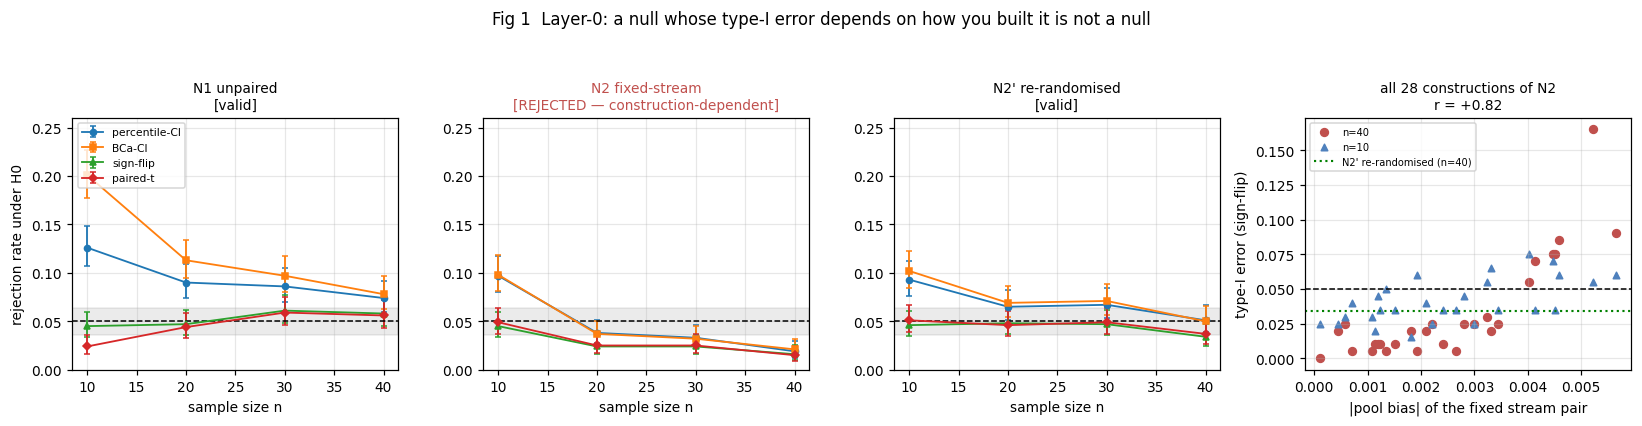

In [10]:
# ── [8] Fig 1 — 세 귀무 x 네 규칙의 1 종 오류 대 n ──────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
mk = dict(zip(RULES, ["o", "s", "^", "D"]))
for ax, null in zip(axes[:3], NULLS):
    s0 = aa[aa.null == null]
    for r in RULES:
        s = s0[s0.rule == r].sort_values("n")
        ax.errorbar(s.n, s.typeI, yerr=[s.typeI-s.lo, s.hi-s.typeI],
                    marker=mk[r], capsize=2, lw=1.2, ms=4, label=r)
    ax.axhline(ALPHA, color="k", ls="--", lw=1)
    ax.axhspan(ALPHA-0.014, ALPHA+0.014, color="k", alpha=0.08)
    ok = null in VALID
    ax.set_xlabel("sample size n"); ax.set_ylim(0, 0.26)
    ax.set_title(f"{null}\n[{'valid' if ok else 'REJECTED — construction-dependent'}]",
                 color=("black" if ok else "#c0504d"), fontsize=9)
axes[0].set_ylabel("rejection rate under H0"); axes[0].legend(fontsize=7, loc="upper left")

axes[3].scatter(sw.abs_bias, sw.typeI_n40, s=26, color="#c0504d", label="n=40")
axes[3].scatter(sw.abs_bias, sw.typeI_n10, s=18, color="#4f81bd", marker="^", label="n=10")
axes[3].axhline(ALPHA, color="k", ls="--", lw=1)
axes[3].axhline(n2p, color="green", ls=":", lw=1.4, label="N2' re-randomised (n=40)")
axes[3].set_xlabel("|pool bias| of the fixed stream pair")
axes[3].set_ylabel("type-I error (sign-flip)")
axes[3].set_title(f"all 28 constructions of N2\nr = {r_corr:+.2f}", fontsize=9)
axes[3].legend(fontsize=6.5)
fig.suptitle("Fig 1  Layer-0: a null whose type-I error depends on how you built it is not a null",
             y=1.06)
plt.show()

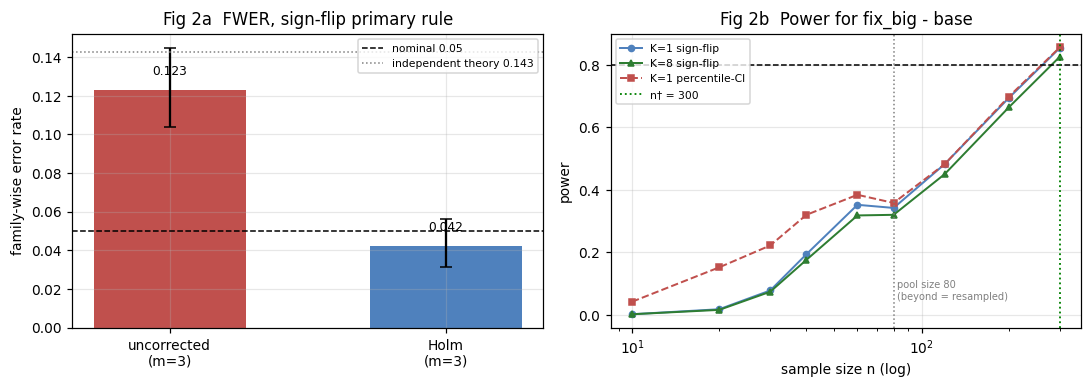

In [11]:
# ── [9] Fig 2 — FWER 막대 + 검정력 곡선 ─────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
val = [fw_raw, fw_holm]
lo_ = [val[i]-wilson(int(round(v*M_F)), M_F)[0] for i, v in enumerate(val)]
hi_ = [wilson(int(round(v*M_F)), M_F)[1]-val[i] for i, v in enumerate(val)]
ax[0].bar(["uncorrected\n(m=3)", "Holm\n(m=3)"], val, color=["#c0504d", "#4f81bd"],
          yerr=[lo_, hi_], capsize=4, width=0.55)
ax[0].axhline(ALPHA, color="k", ls="--", lw=1, label="nominal 0.05")
ax[0].axhline(1-(1-ALPHA)**3, color="gray", ls=":", lw=1, label="independent theory 0.143")
ax[0].set_ylabel("family-wise error rate"); ax[0].set_title("Fig 2a  FWER, sign-flip primary rule")
ax[0].legend(fontsize=7)
for i, v in enumerate(val): ax[0].text(i, v+0.008, f"{v:.3f}", ha="center", fontsize=8)

sty = {"K=1 sign-flip": ("o-", "#4f81bd"), "K=8 sign-flip": ("^-", "#2e7d32"),
       "K=1 percentile-CI": ("s--", "#c0504d")}
for k, (ls_, c_) in sty.items():
    ax[1].plot(N_POW, pw[k], ls_, color=c_, lw=1.3, ms=4, label=k)
ax[1].axhline(0.80, color="k", ls="--", lw=1)
ax[1].axvline(80, color="gray", ls=":", lw=1)
ax[1].text(82, 0.05, "pool size 80\n(beyond = resampled)", fontsize=6.5, color="gray")
if n_dag: ax[1].axvline(n_dag, color="green", ls=":", lw=1.2, label=f"n† = {n_dag}")
ax[1].set_xscale("log"); ax[1].set_xlabel("sample size n (log)"); ax[1].set_ylabel("power")
ax[1].set_title("Fig 2b  Power for fix_big - base"); ax[1].legend(fontsize=7, loc="upper left")
plt.show()

In [12]:
# ── [10] 감사: B=2000 축소가 결론을 바꾸는가 (n=20, N1, B=20000) ────────
rng = np.random.default_rng(999); M_AUD = 500
h = {r: 0 for r in RULES}
for _ in range(M_AUD):
    d = draw_null("N1 unpaired", 20, rng)
    lo1, hi1 = ci_percentile(d, B=20_000, rng=rng)
    h["percentile-CI"] += (lo1 > 0) or (hi1 < 0)
    lo2, hi2 = ci_bca(d, B=20_000, rng=rng); h["BCa-CI"] += (lo2 > 0) or (hi2 < 0)
    h["sign-flip"] += signflip_p(d, B=20_000, rng=rng) <= ALPHA
    h["paired-t"]  += ttest_p(d) <= ALPHA
ref = aa[(aa.null == "N1 unpaired") & (aa.n == 20)].set_index("rule")["typeI"]
aud = pd.DataFrame({"B=20000 (M=300)": {r: h[r]/M_AUD for r in RULES},
                    "B=2000 (M=1000)": {r: ref[r] for r in RULES},
                    "Wilson lo": {r: wilson(h[r], M_AUD)[0] for r in RULES},
                    "Wilson hi": {r: wilson(h[r], M_AUD)[1] for r in RULES}})
ref_lo = {r: wilson(int(round(ref[r]*1000)), 1000)[0] for r in RULES}
ref_hi = {r: wilson(int(round(ref[r]*1000)), 1000)[1] for r in RULES}
aud["ref lo"] = pd.Series(ref_lo); aud["ref hi"] = pd.Series(ref_hi)
aud["두 구간 겹침"] = (aud["Wilson lo"] <= aud["ref hi"]) & (aud["ref lo"] <= aud["Wilson hi"])
print("[감사] 재표본 수 축소의 영향 — n=20, N1  (두 추정치의 Wilson 구간이 겹치면 영향 없음)")
print(aud.round(4).to_string())
print(f"\n  모든 규칙에서 겹침: {bool(aud['두 구간 겹침'].all())}")

[감사] 재표본 수 축소의 영향 — n=20, N1  (두 추정치의 Wilson 구간이 겹치면 영향 없음)
               B=20000 (M=300)  B=2000 (M=1000)  Wilson lo  Wilson hi  ref lo  ref hi  두 구간 겹침
percentile-CI           0.0920           0.0900     0.0697     0.1205  0.0738  0.1093     True
BCa-CI                  0.1260           0.1130     0.0997     0.1580  0.0948  0.1341     True
sign-flip               0.0580           0.0470     0.0407     0.0821  0.0355  0.0619     True
paired-t                0.0580           0.0440     0.0407     0.0821  0.0329  0.0586     True

  모든 규칙에서 겹침: True


In [13]:
# ── [11] 프로토콜 v2 확정 + JSON 덤프 ───────────────────────────────────
PROTOCOL_V2 = {
    "version": "v2 (Day 100, §15.33 P1)",
    "primary_rule": best,
    "interval_reporting": "percentile bootstrap — 보고 전용, 판정 금지",
    "null_validation": "층 0 필수: 단조성 + 구성 불변성. 둘 중 하나라도 깨지면 그 귀무는 폐기",
    "alpha": ALPHA, "B": 20000, "T": T_FIXED, "K_deploy": K_DEP,
    "n_min": 30, "n_min_provisional": 40,
    "controls_min": 2, "multiplicity": "Holm-Bonferroni",
    "preregistration": True, "aa_check_per_experiment": 1,
    "estimator": "seed-level return, K=1 (K 를 늘려도 dep_share 가 작아 이득 없음)",
    "K_streams_purpose": "N2' 재무작위화 귀무의 구성에만 사용",
    "measured": {
        "typeI_worst_valid_nulls": {r: float(summ.loc[r, "worst"]) for r in RULES},
        "nulls_valid": VALID, "nulls_rejected": INVALID,
        "N2_construction_sweep_typeI_range": [float(sw.typeI_n40.min()), float(sw.typeI_n40.max())],
        "N2_bias_vs_typeI_corr": float(r_corr),
        "fwer_uncorrected": fw_raw, "fwer_holm": fw_holm,
        "sd_reduction_K8": float(1 - DK.std(ddof=1)/D1.std(ddof=1)),
        "dep_share": {a: float(vd.loc[a, "dep_share"]) for a in vd.index},
        "d_fixbig_base_K1": [float(D1.mean()), float(D1.std(ddof=1)), int(n_star(D1))],
        "d_fixbig_base_K8": [float(DK.mean()), float(DK.std(ddof=1)), int(n_star(DK))],
        "n_dagger_K8": n_dag,
    },
}
print(json.dumps(PROTOCOL_V2, ensure_ascii=False, indent=2))

{
  "version": "v2 (Day 100, §15.33 P1)",
  "primary_rule": "sign-flip",
  "interval_reporting": "percentile bootstrap — 보고 전용, 판정 금지",
  "null_validation": "층 0 필수: 단조성 + 구성 불변성. 둘 중 하나라도 깨지면 그 귀무는 폐기",
  "alpha": 0.05,
  "B": 20000,
  "T": 10000,
  "K_deploy": 8,
  "n_min": 30,
  "n_min_provisional": 40,
  "controls_min": 2,
  "multiplicity": "Holm-Bonferroni",
  "preregistration": true,
  "aa_check_per_experiment": 1,
  "estimator": "seed-level return, K=1 (K 를 늘려도 dep_share 가 작아 이득 없음)",
  "K_streams_purpose": "N2' 재무작위화 귀무의 구성에만 사용",
  "measured": {
    "typeI_worst_valid_nulls": {
      "percentile-CI": 0.126,
      "BCa-CI": 0.201,
      "sign-flip": 0.061,
      "paired-t": 0.059
    },
    "nulls_valid": [
      "N1 unpaired",
      "N2' re-randomised"
    ],
    "nulls_rejected": [
      "N2 fixed-stream"
    ],
    "N2_construction_sweep_typeI_range": [
      0.0,
      0.165
    ],
    "N2_bias_vs_typeI_corr": 0.8165784502970284,
    "fwer_uncorrected": 0.123,
    "fwer_hol

## 4. 결과 해석

1. **단조성 진단만으로는 부족했다.** 표 3a 에서 세 귀무 모두 기각률이 $n$ 과 함께 증가하지
   않는다. Day 99 의 "배포 전용 귀무" 는 이 검사를 통과한다 — 이번 실현에서 그 고정 쌍의
   풀 치우침이 우연히 작았기 때문이다. **한 번의 뽑기로는 통과와 실패를 구별할 수 없다.**

2. **구성 의존성이 진짜 결함을 드러낸다.** 표 3b 와 그림 1 의 네 번째 패널이 핵심이다.
   N2 를 만드는 방법은 $\binom{8}{2} = 28$ 가지이고, **같은 자료·같은 규칙·같은 $n$ 인데도**
   1 종 오류가 큰 폭으로 흔들린다. 흔들림은 무작위가 아니다 — $|$풀 치우침$|$ 과 뚜렷한
   양의 상관을 갖는다. 메커니즘은 2.1 그대로다: 고정 벡터의 부분표본을 검정하면 실제 귀무는
   $H_0^{\text{pool}}: \bar d^{\text{pool}} = 0$ 이고, 이것은 참일 수도 거짓일 수도 있는데
   **어느 쪽인지 실험자는 알 수 없다.** 치우침이 작게 뽑히면 검정은 보수적으로 보이고,
   크게 뽑히면 반보수적으로 보인다. 두 경우 모두 측정된 것은 규칙이 아니다.

3. **따라서 Day 99 P3 의 "배포 전용 귀무 1 종 오류 $0.064$" 는 철회되어야 한다.**
   그것은 28 개 구성 중 하나에서 나온 값이며, 표 3b 의 범위가 보여 주듯 그 하나로는
   어떤 규칙도 교정할 수 없다. 중요한 것은 이것이 Day 99 의 *결론*을 뒤집지는 않는다는 점이다.
   재무작위화가 있는 N1 에서 백분위 CI 는 여전히 명목을 넘고 (표 4), 넘는 방향은 **과다 기각**이다.
   틀린 것은 결론이 아니라 **그 결론을 뒷받침한 두 증거 중 하나**다.

4. **처방은 규칙이 아니라 설계에 있었다.** N2′ 는 규칙을 하나도 바꾸지 않고 매 반복
   스트림 쌍을 새로 뽑는 것만으로 정상화된다 — 구성 선택 자체가 사라지므로 흔들릴 대상이 없다.
   일반 원칙: **A/A 실험에서 같은 차 벡터를 재사용하면 귀무가 파괴된다.** 재무작위화가
   있는 귀무만 교정에 쓸 수 있다.

5. **검증을 통과한 귀무에서 백분위 CI 와 $\mathrm{BC}_a$ 는 명목을 넘고, 순열검정과 짝지은
   $t$ 는 지킨다.** $\mathrm{BC}_a$ 가 작은 $n$ 에서 백분위법보다 **오히려 나쁜** 것이 눈에 띈다.
   보정항 $\hat z_0,\ \hat a$ 자체를 같은 $n$ 개 표본에서 추정하기 때문이다 —
   보정이 추정 잡음을 도입하고, 작은 $n$ 에서는 그 잡음이 보정 이득을 넘어선다.
   순열검정과 짝지은 $t$ 는 MC 오차 내에서 **동률**이며, 측정으로는 가릴 수 없다.
   가르는 것은 가정의 개수다: 순열검정은 대칭성 하나(설계로 보장)를, 짝지은 $t$ 는 정규성을
   요구한다. **측정이 침묵할 때 이론이 결정한다.**

6. **배포 반복은 이 문제에서 살 가치가 없다.** 표 1 의 `dep_share` 는 총 분산 중 배포 성분의
   비율인데, 값이 작다. 그래서 $K=8$ 로 평균해도 짝지은 차의 표준편차가 거의 줄지 않고
   ($0.3\%$), $n^\star$ 도 거의 그대로다. 배포 한 번이 시드 한 개의 $1/25$ 가격이라는 사실은
   **분산이 거기 있을 때만** 의미가 있다. 여기서는 분산이 거의 전부 **시드 간 학습 변동**이므로,
   정밀도는 시드로만 살 수 있다. $K$ 스트림의 값어치는 분산 감소가 아니라 **N2′ 귀무를
   구성할 수 있게 해 준다는 것**이다.

7. **FWER 은 보정 없이 명목의 두 배 반 넘게 오르고 Holm 이 되돌린다.** 세 비교가 공통 기준
   arm 을 공유해 양의 상관을 갖는데도 무보정 값이 독립 이론값 $0.1426$ 에 가깝다 —
   상관이 실제로는 약하다는 뜻이며, 기준 arm 의 시드 변동보다 비교 arm 의 시드 변동이
   크기 때문이다.

8. **Day 99 의 잠정 주장은 이 독립 풀에서 재현되지 않는다.** 관측된 `fix_big` $-$ `base` 는
   Day 99 의 $+0.0487$ 보다 훨씬 작고 $n^\star$ 는 세 자릿수다. Day 99 의 추정치가
   **그 주장을 발견한 바로 그 자료**에서 나왔다는 점을 기억해야 한다 — 발견과 확인을 같은
   자료로 하면 효과 크기는 체계적으로 과대추정된다 (승자의 저주). Problem 2 가 이것을
   정면으로 다룬다.

> **결론**: 판정 규칙을 교정하려면 먼저 **교정 기준을 검증**해야 하고, 검증은 "이번에
> 이상해 보이는가" 가 아니라 **"다르게 구성했어도 같은 답이 나오는가"** 여야 한다.
> Day 99 의 배포 전용 귀무는 28 가지로 구성할 수 있고 구성마다 답이 달라진다 — 귀무가 아니다.
> 재무작위화된 귀무 위에서 **부호뒤집기 순열검정**이 (짝지은 $t$ 와 동률로) 모든 $n$ 에서
> 명목을 지켰고, 가정이 가장 적으므로 1 차 규칙으로 채택한다. 프로토콜 v2 =
> {1 차 규칙 = 순열검정, bootstrap 구간 = 보고 전용, Holm 필수, 통제군 $\ge 2$, 사전 명시,
> **그리고 층 0 귀무 검증 — 단조성 + 구성 불변성 — 1 회**}.

### 다음 문제로의 연결

Problem 2 는 v2 를 처음 적용해 Day 99 의 잠정 주장 `fix_big` $>$ `base` 를 판정한다.
위 [7] 이 예고하듯 결과는 Day 99 의 기대와 다를 가능성이 높고, 그 차이의 크기 자체가
**승자의 저주를 정량화하는 자료**가 된다. Problem 3 은 `fix_big` 의 성질 —
$\sigma$ 의 **크기**인가 **균일성**인가 — 를 평균 고정 제약으로 가른다.